Trying to build a hybrid predictive model which predicts the upcoming disaster.

The dataset is provided from EM-DAT which is genuine.

Data Preprocessing

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import shap


df = pd.read_excel("EM-DAT_dataset.xlsx")

print("Original Shape:", df.shape)

#  FILTER REQUIRED DISASTER TYPES

target_column = "Disaster Type"   # Replace if column name differs

selected_classes = ["Wildfire", "Flood", "Earthquake"]

df = df[df[target_column].isin(selected_classes)].copy()

print("After Filtering Shape:", df.shape)
print("Class Distribution Before Balancing:")
print(df[target_column].value_counts())

#  HANDLE MISSING VALUES

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Median Imputation
num_imputer = SimpleImputer(strategy='median')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

# Mode Imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

print("Missing values after imputation:", X.isnull().sum().sum())


# ENCODE CATEGORICAL VARIABLES

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

#  NORMALIZE NUMERICAL FEATURES

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

#  TRAIN-TEST SPLIT (70:30 HOLDOUT)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# 7. APPLY SMOTE (ONLY ON TRAINING SET)
# p_new = p + λ(p_nn - p)

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Class Distribution After SMOTE:")
print(pd.Series(y_train_balanced).value_counts())


print("\nPreprocessing Completed Successfully")


Original Shape: (5369, 47)
After Filtering Shape: (2776, 47)
Class Distribution Before Balancing:
Disaster Type
Flood         2152
Earthquake     501
Wildfire       123
Name: count, dtype: int64
Missing values after imputation: 0
Training Shape: (1943, 46)
Testing Shape: (833, 46)
Class Distribution After SMOTE:
1    1506
0    1506
2    1506
Name: count, dtype: int64

Preprocessing Completed Successfully


Feature Extraction

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert to tensors

X_train_tensor = torch.tensor(X_train_balanced.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_balanced, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

input_dim = X_train_tensor.shape[1]
num_classes = len(set(y_train_balanced))

# Neural Network Model

class NeuralFeatureModel(nn.Module):
    def __init__(self):
        super(NeuralFeatureModel, self).__init__()

        # Feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),   # Final feature dimension (P < N)
            nn.ReLU()
        )

        # Classification head (only for training)
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.classifier(features)
        return output

model = NeuralFeatureModel()


# Training Setup

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50

# Train Network

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss:.4f}")

print("Neural Network Training Completed")


# Extract Deep Features (H)

model.eval()

with torch.no_grad():
    H_train = model.feature_extractor(X_train_tensor).numpy()
    H_test = model.feature_extractor(X_test_tensor).numpy()

print("Feature Extraction Completed")
print("H_train shape:", H_train.shape)
print("H_test shape:", H_test.shape)

Epoch [1/50] Loss: 293.6404
Epoch [2/50] Loss: 90.1436
Epoch [3/50] Loss: 79.2278
Epoch [4/50] Loss: 76.6127
Epoch [5/50] Loss: 75.0669
Epoch [6/50] Loss: 72.9152
Epoch [7/50] Loss: 70.7657
Epoch [8/50] Loss: 68.4255
Epoch [9/50] Loss: 67.3039
Epoch [10/50] Loss: 65.5372
Epoch [11/50] Loss: 64.5223
Epoch [12/50] Loss: 63.2524
Epoch [13/50] Loss: 61.5931
Epoch [14/50] Loss: 61.1631
Epoch [15/50] Loss: 61.0798
Epoch [16/50] Loss: 58.3051
Epoch [17/50] Loss: 57.2735
Epoch [18/50] Loss: 56.0384
Epoch [19/50] Loss: 54.4466
Epoch [20/50] Loss: 53.2326
Epoch [21/50] Loss: 51.1737
Epoch [22/50] Loss: 49.1310
Epoch [23/50] Loss: 47.0020
Epoch [24/50] Loss: 45.7550
Epoch [25/50] Loss: 45.0152
Epoch [26/50] Loss: 43.2200
Epoch [27/50] Loss: 40.6223
Epoch [28/50] Loss: 40.2485
Epoch [29/50] Loss: 37.4701
Epoch [30/50] Loss: 36.6728
Epoch [31/50] Loss: 34.4308
Epoch [32/50] Loss: 31.9672
Epoch [33/50] Loss: 31.8837
Epoch [34/50] Loss: 30.3766
Epoch [35/50] Loss: 29.9449
Epoch [36/50] Loss: 30.0724


XGBoost implementation

In [12]:

# XGBoost on Deep Extracted Features

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Define XGBoost Model

xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Hyperparameter Grid

param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'n_estimators': [200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Train on Deep Features

grid_search.fit(H_train, y_train_balanced)

best_xgb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:10:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


Evaluate on Test Set

In [ ]:
# Predict
y_pred = best_xgb.predict(H_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9711884753901561

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       150
           1       0.99      0.98      0.98       646
           2       1.00      0.86      0.93        37

    accuracy                           0.97       833
   macro avg       0.96      0.93      0.95       833
weighted avg       0.97      0.97      0.97       833



Confusion Matrix

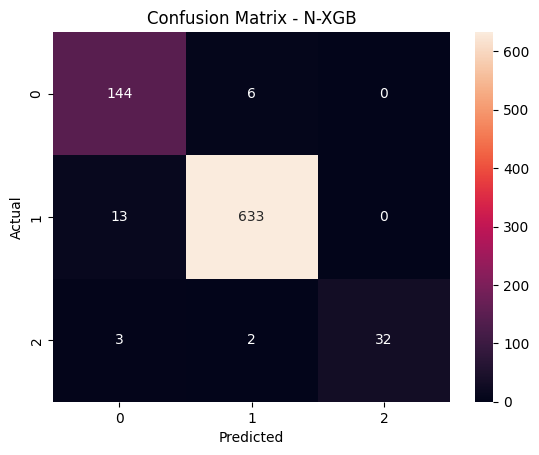

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - N-XGB")
plt.show()

ROC-AUC Curve

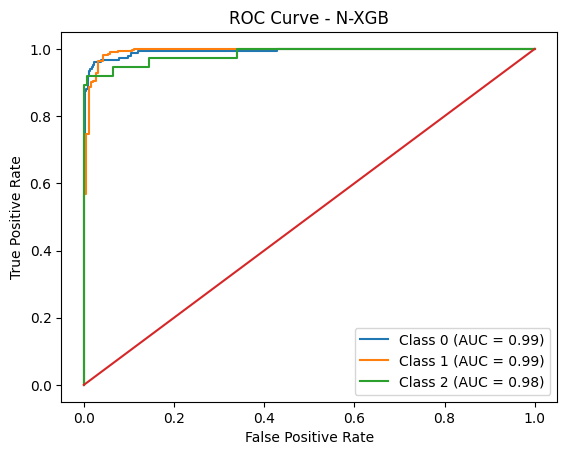

In [ ]:
from sklearn.metrics import roc_curve, auc

# Binarize labels
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_score = best_xgb.predict_proba(H_test)

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - N-XGB")
plt.legend()
plt.show()

Extending my research......
Add  Explainability towards results......

SHAP (SHapley Additive exPlanations) is used to interpret model predictions by quantifying the contribution of each feature toward the final prediction.

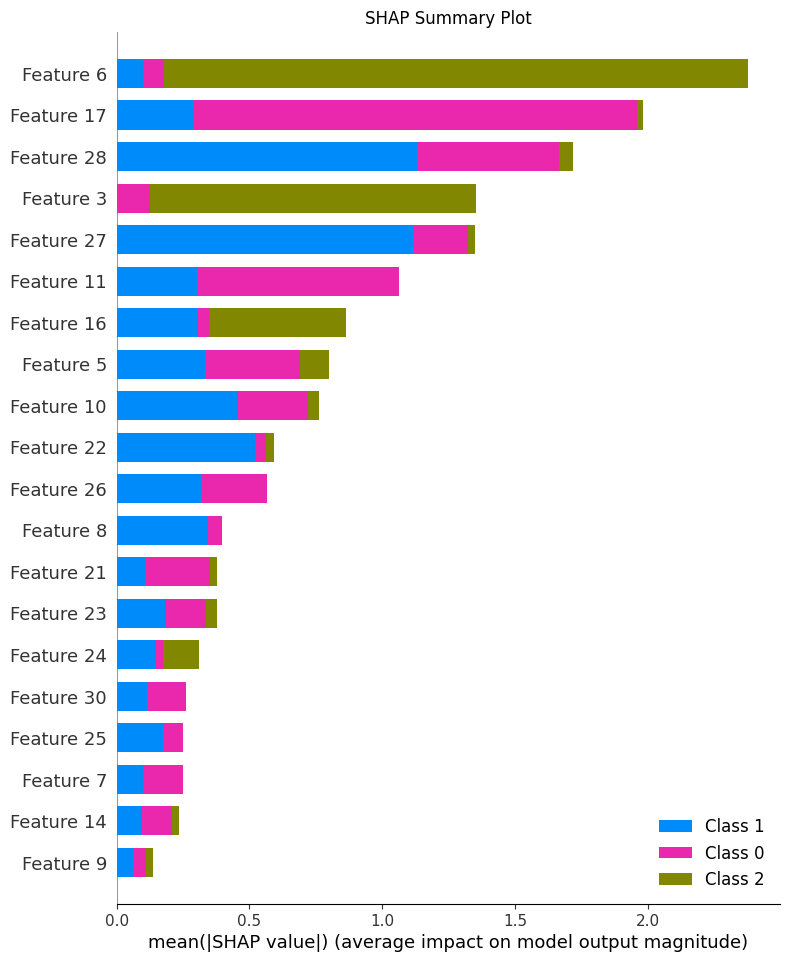

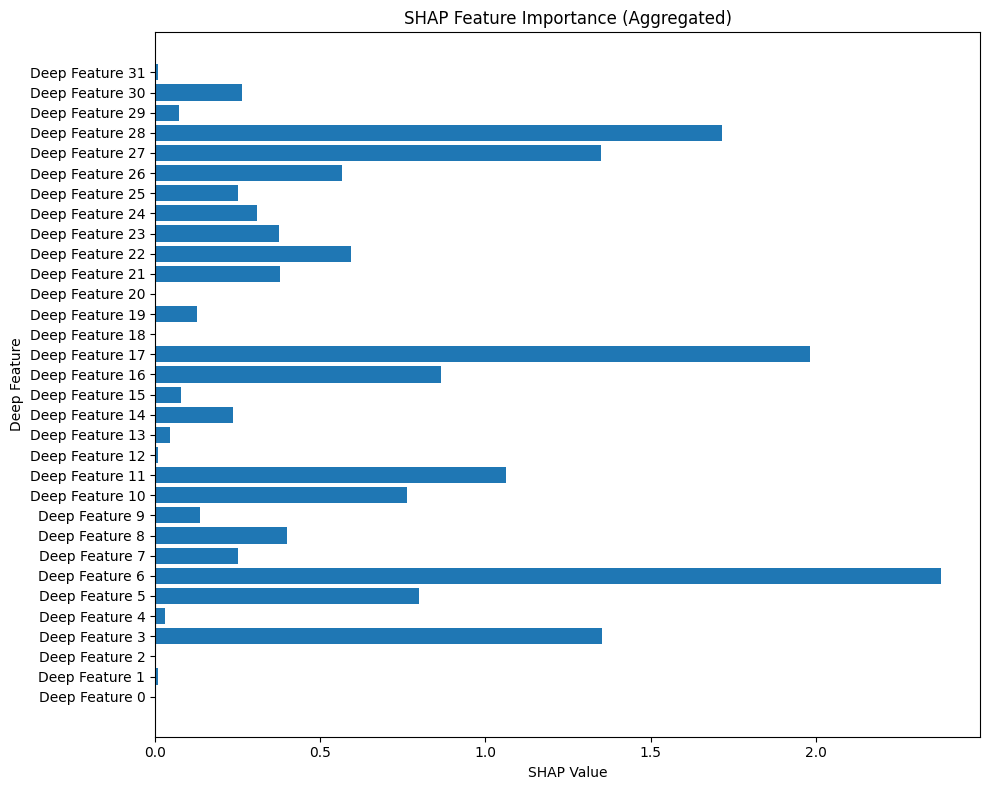

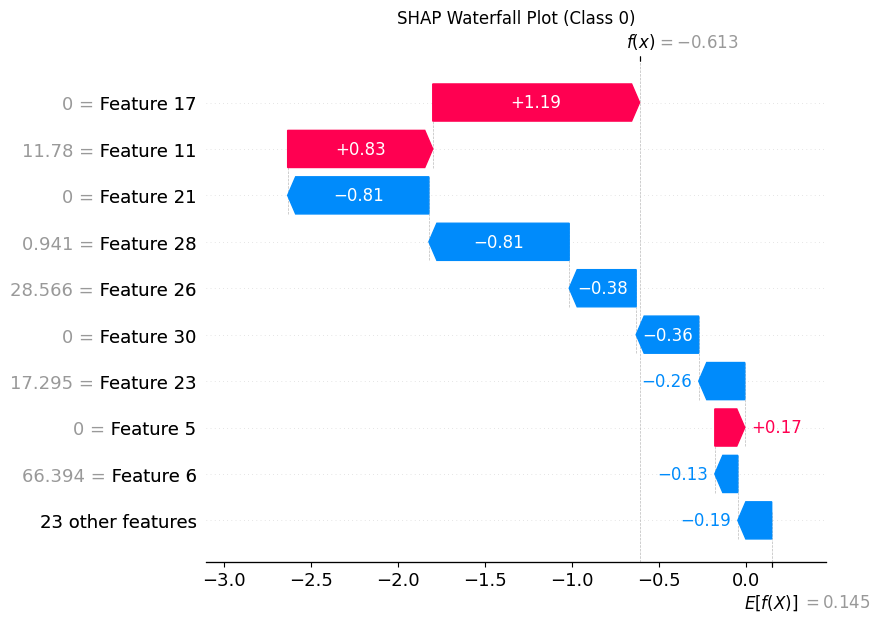

In [19]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(best_xgb)
shap_values = explainer(H_test)

# Summary Plot
shap.summary_plot(shap_values, H_test, show=False)
plt.title("SHAP Summary Plot")
plt.show()

# Aggregated Feature Importance
overall_feature_importance = shap_values.abs.mean(0).values.sum(axis=1)
deep_feature_names = [f'Deep Feature {i}' for i in range(H_test.shape[1])]

plt.figure(figsize=(10, 8))
plt.barh(deep_feature_names, overall_feature_importance)
plt.xlabel("SHAP Value")
plt.ylabel("Deep Feature")
plt.title("SHAP Feature Importance (Aggregated)")
plt.tight_layout()
plt.show()

# Waterfall Plot (FIXED)
shap.plots.waterfall(shap_values[0, :, 0], show=False)
plt.title("SHAP Waterfall Plot (Class 0)")
plt.show()